# Numerikus módszerek – 1. előadás
## Bevezetés, lebegőpontos számábrázolás

Ez a notebook a Numerikus módszerek tárgy 1. előadásához tartalmaz **konkrét példákat** Python nyelven.

**Témák:**
1. Matematikai modellezés és hibaforrások
2. "Furcsa jelenségek" – numerikus meglepetések
3. Algoritmus stabilitása
4. Lebegőpontos számábrázolás
5. Input hiba
6. Hibák terjedése, kondíciószám

In [1]:
import numpy as np
import matplotlib.pyplot as plt

---
## 1. Matematikai modellezés és hibaforrások

A numerikus számítások során többféle hiba jelenik meg:

| Hiba típusa | Eredete |
|---|---|
| **Modellhiba** | A valóság egyszerűsítése (pl. légellenállás elhanyagolása) |
| **Képlethiba** | Végtelen eljárás végessel való helyettesítése (pl. Taylor-sor csonkítása) |
| **Mérési (input) hiba** | A bemenő adatok pontatlan méréséből ered |
| **Kerekítési hiba** | A véges aritmetikában történő számolás során keletkezik |

### Példa: Szabadesés modellezése

Két modell összehasonlítása:
- **Egyszerű modell:** $h(t) = h_0 - \frac{1}{2}g t^2$ (légellenállás nélkül)
- **Pontosabb modell:** légellenállással ($F_d = -c \cdot v$)

A két modell közötti eltérés a **modellhiba**.

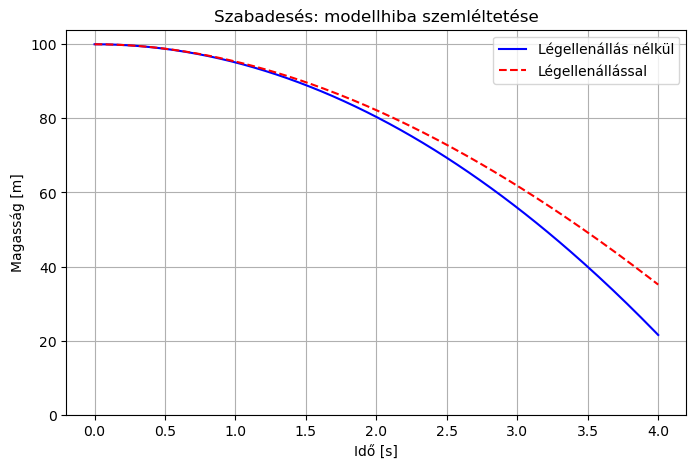

Eltérés t=3s-nál: 5.94 m
Eltérés t=4s-nál: 13.60 m


In [2]:
# Szabadesés modellezése: légellenállással vs. anélkül
g = 9.81       # gravitációs gyorsulás [m/s^2]
h0 = 100.0     # kezdő magasság [m]
m = 80.0       # tömeg [kg]
c = 12.0       # légellenállási együtható [kg/s]

t = np.linspace(0, 4, 200)

# 1. modell: légellenállás nélkül
h_egyszeru = h0 - 0.5 * g * t**2

# 2. modell: lineáris légellenállással (analitikus megoldás)
# m*v' = -m*g + c*v  =>  h(t) = h0 + (m/c)*(m*g/c)*(1 - exp(-c*t/m)) - (m*g/c)*t
tau = m / c  # időállandó
v_term = m * g / c  # határsebesség
h_legellenallas = h0 + v_term * tau * (1 - np.exp(-t / tau)) - v_term * t

plt.figure(figsize=(8, 5))
plt.plot(t, h_egyszeru, 'b-', label='Légellenállás nélkül')
plt.plot(t, h_legellenallas, 'r--', label='Légellenállással')
plt.xlabel('Idő [s]')
plt.ylabel('Magasság [m]')
plt.title('Szabadesés: modellhiba szemléltetése')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.show()

print(f'Eltérés t=3s-nál: {abs(np.interp(3, t, h_egyszeru) - np.interp(3, t, h_legellenallas)):.2f} m')
print(f'Eltérés t=4s-nál: {abs(np.interp(4, t, h_egyszeru) - np.interp(4, t, h_legellenallas)):.2f} m')

---
## 2. Furcsa jelenségek a számítógépes aritmetikában

### 2.1. Mennyi $\cos(\pi/2)$ értéke?

Tudjuk, hogy $\cos(\pi/2) = 0$, de a számítógép mást mond...

In [3]:
# cos(pi/2) elméletben 0
print(f'cos(π/2) = {np.cos(np.pi/2)}')
print(f'tan(π)   = {np.tan(np.pi)}')
print(f'sin(2π) = {np.sin(2*np.pi)}')
print()
print('Egyik sem pontosan 0!')
print(f'Ez azért van, mert π-t sem tudjuk pontosan ábrázolni: repr(π) = {np.pi!r}')

cos(π/2) = 6.123233995736766e-17
tan(π)   = -1.2246467991473532e-16
sin(2π) = -2.4492935982947064e-16

Egyik sem pontosan 0!
Ez azért van, mert π-t sem tudjuk pontosan ábrázolni: repr(π) = 3.141592653589793


### 2.2. Összegzés iránya: $\sum_{k=1}^{n} \frac{1}{k^2}$

Tudjuk, hogy $\sum_{k=1}^{\infty} \frac{1}{k^2} = \frac{\pi^2}{6}$. Számoljuk ki az első $n$ tag összegét **előre** (nagy tagoktól) és **hátra** (kis tagoktól) haladva!

In [4]:
n = 10_000_000
elmeleti = np.pi**2 / 6

# Előre összegzés: 1/1² + 1/2² + 1/3² + ... (nagy tagoktól a kicsik felé)
osszeg_elore = np.float64(0.0)
for k in range(1, n + 1):
    osszeg_elore += np.float64(1.0 / k**2)

# Hátra összegzés: ... + 1/3² + 1/2² + 1/1² (kis tagoktól a nagyok felé)
osszeg_hatra = np.float64(0.0)
for k in range(n, 0, -1):
    osszeg_hatra += np.float64(1.0 / k**2)

print(f'Elméleti érték (π²/6): {elmeleti:.16f}')
print(f'Előre összegzés:       {osszeg_elore:.16f}')
print(f'Hátra összegzés:       {osszeg_hatra:.16f}')
print(f'Különbség (hátra - előre): {osszeg_hatra - osszeg_elore:.2e}')
print()

# Ugyanez float32-ben – itt sokkal látványosabb
print('--- Ugyanez float32-ben (n=100000) ---')
n32 = 100_000
osszeg_elore32 = np.float32(0.0)
for k in range(1, n32 + 1):
    osszeg_elore32 += np.float32(1.0 / k**2)

osszeg_hatra32 = np.float32(0.0)
for k in range(n32, 0, -1):
    osszeg_hatra32 += np.float32(1.0 / k**2)

print(f'Előre összegzés (float32): {osszeg_elore32}')
print(f'Hátra összegzés (float32): {osszeg_hatra32}')
print(f'Különbség:                 {float(osszeg_hatra32 - osszeg_elore32):.6e}')
print()
print('A hátra összegzés pontosabb, mert a kis tagokat nem veszítjük el')
print('a már nagy részletösszeg mellett.')

Elméleti érték (π²/6): 1.6449340668482264
Előre összegzés:       1.6449339668472596
Hátra összegzés:       1.6449339668482315
Különbség (hátra - előre): 9.72e-13

--- Ugyanez float32-ben (n=100000) ---
Előre összegzés (float32): 1.6447253227233887
Hátra összegzés (float32): 1.6449240446090698
Különbség:                 1.987219e-04

A hátra összegzés pontosabb, mert a kis tagokat nem veszítjük el
a már nagy részletösszeg mellett.


### 2.3. Katasztrofális kioltás: nagy számok különbsége

Számítsuk ki $\sqrt{10000001} - \sqrt{10000000}$ értékét kétféleképpen!

A konjugált alak:
$$\sqrt{a} - \sqrt{b} = \frac{a - b}{\sqrt{a} + \sqrt{b}}$$

In [5]:
a = 10000001
b = 10000000

# Közvetlen különbség (kioltás!)
eredmeny1 = np.sqrt(a) - np.sqrt(b)

# Konjugált alak (stabil)
eredmeny2 = (a - b) / (np.sqrt(a) + np.sqrt(b))

print(f'Közvetlen különbség:  {eredmeny1:.16e}')
print(f'Konjugált alak:       {eredmeny2:.16e}')
print(f'Eltérés:              {abs(eredmeny1 - eredmeny2):.2e}')
print()
print('A közvetlen kivonásnál a két szám számos jegye megegyezik,')
print('ezért a kivonás után csak kevés értékes jegy marad.')

Közvetlen különbség:  1.5811387902431306e-04
Konjugált alak:       1.5811387905557208e-04
Eltérés:              3.13e-14

A közvetlen kivonásnál a két szám számos jegye megegyezik,
ezért a kivonás után csak kevés értékes jegy marad.


### 2.4. Asszociativitás sérülése

A valós számok körében $(a + b) - b = a + (b - b)$. Igaz-e ez a gépi számokra?

In [6]:
a = 1e-16
b = 2.0

bal = (a + b) - b
jobb = a + (b - b)

print(f'a = {a}, b = {b}')
print()
print(f'(a + b) - b = ({a} + {b}) - {b}')
print(f'            = {a + b} - {b}')
print(f'            = {bal}')
print()
print(f'a + (b - b) = {a} + ({b} - {b})')
print(f'            = {a} + {b - b}')
print(f'            = {jobb}')
print()
print(f'A két eredmény egyenlő? {bal == jobb}')
print()
print(f'Magyarázat: a + b = {a + b}, mert az {a} "elveszik" a {b} mellett')
print(f'(a gépi epszilon 2-nél: {2 * np.finfo(float).eps:.2e} > {a}).')

a = 1e-16, b = 2.0

(a + b) - b = (1e-16 + 2.0) - 2.0
            = 2.0 - 2.0
            = 0.0

a + (b - b) = 1e-16 + (2.0 - 2.0)
            = 1e-16 + 0.0
            = 1e-16

A két eredmény egyenlő? False

Magyarázat: a + b = 2.0, mert az 1e-16 "elveszik" a 2.0 mellett
(a gépi epszilon 2-nél: 4.44e-16 > 1e-16).


### 2.5. Kioltás: $e^x$ két alakja

Tudjuk, hogy $\cosh(x) - \sinh(x) = e^{-x}$. Próbáljuk ki nagy $x$-re!

In [7]:
x = 30

# Közvetlen: cosh(x) - sinh(x)
eredmeny_cosh_sinh = np.cosh(x) - np.sinh(x)

# Elméleti: exp(-x)
eredmeny_exp = np.exp(-x)

print(f'x = {x}')
print(f'cosh({x}) - sinh({x}) = {eredmeny_cosh_sinh:.15e}')
print(f'exp(-{x})             = {eredmeny_exp:.15e}')
print(f'Eltérés:                {abs(eredmeny_cosh_sinh - eredmeny_exp):.2e}')
print()

# Még látványosabb: (e^x + e^{-x})/2 - (e^x - e^{-x})/2 kézzel
ex = np.exp(x)
emx = np.exp(-x)
kezi = (ex + emx) / 2 - (ex - emx) / 2
print(f'Kézi számolás:       {kezi:.15e}')
print(f'exp({x})  = {ex:.6e} – hatalmas szám, exp(-{x}) „elveszik” mellette')

x = 30
cosh(30) - sinh(30) = 0.000000000000000e+00
exp(-30)             = 9.357622968840175e-14
Eltérés:                9.36e-14

Kézi számolás:       0.000000000000000e+00
exp(30)  = 1.068647e+13 – hatalmas szám, exp(-30) „elveszik” mellette


### 2.6. Instabil rekurzió

Legyen $I_n = \int_0^1 x^n e^{x-1} dx$. Integrálással kapjuk:
$$I_n = 1 - n \cdot I_{n-1}, \quad I_0 = 1 - e^{-1}.$$

Ez a rekurzió **előre** instabil (a hiba $n!$-sal szorzódik).

**Hátra** rekurzió: $I_{n-1} = \frac{1 - I_n}{n}$ valamilyen nagy $M$-ből indulva, $I_M \approx 0$.

In [8]:
from scipy.integrate import quad

# Pontos érték numerikus integrálással
def pontos_I(n):
    val, _ = quad(lambda x: x**n * np.exp(x - 1), 0, 1)
    return val

# Előre rekurzió (INSTABIL)
N = 25
I_elore = np.zeros(N + 1)
I_elore[0] = 1 - np.exp(-1)
for n in range(1, N + 1):
    I_elore[n] = 1 - n * I_elore[n - 1]

# Hátra rekurzió (STABIL)
M = 50  # nagy indexből indulunk
I_hatra_list = np.zeros(M + 1)
I_hatra_list[M] = 0  # közelítő kezdőérték
for n in range(M, 0, -1):
    I_hatra_list[n - 1] = (1 - I_hatra_list[n]) / n

print(f'{"n":>3s}  {"Előre":>18s}  {"Hátra":>18s}  {"Pontos (quad)":>18s}')
print('-' * 65)
for n in range(0, N + 1, 5):
    p = pontos_I(n)
    print(f'{n:3d}  {I_elore[n]:18.12f}  {I_hatra_list[n]:18.12f}  {p:18.12f}')

print()
print('Az előre rekurzió növekvő n-re teljesen elromlik!')
print('A hátra rekurzió stabil, mert a hibát 1/n-nel osztjuk minden lépésben.')

  n               Előre               Hátra       Pontos (quad)
-----------------------------------------------------------------
  0      0.632120558829      0.632120558829      0.632120558829
  5      0.145532940573      0.145532940573      0.145532940573
 10      0.083877070058      0.083877070103      0.083877070103
 15      0.059033793642      0.059017540879      0.059017540879
 20    -30.192394885584      0.045544884076      0.045544884076
 25  192785008.832527965307      0.037086214424      0.037086214424

Az előre rekurzió növekvő n-re teljesen elromlik!
A hátra rekurzió stabil, mert a hibát 1/n-nel osztjuk minden lépésben.


---
## 3. Algoritmus stabilitása

Egy numerikus algoritmus **stabil**, ha létezik $C > 0$ konstans, hogy a $B_1, B_2$ bemenő adatokból kapott $K_1, K_2$ kimeneti adatokra:
$$\|K_1 - K_2\| \le C \cdot \|B_1 - B_2\|.$$

### Példa: Fibonacci-sorozat a Binet-formulával

A Fibonacci-számok: $F_0 = 0, F_1 = 1, F_n = F_{n-1} + F_{n-2}$.

Binet-formula: $F_n = \frac{\varphi^n - \psi^n}{\sqrt{5}}$, ahol $\varphi = \frac{1+\sqrt{5}}{2}, \psi = \frac{1-\sqrt{5}}{2}$.

A Binet-formula **instabil**, mert két nagy, közel azonos szám különbségét képezzük.

In [9]:
phi = (1 + np.sqrt(5)) / 2
psi = (1 - np.sqrt(5)) / 2

def fibonacci_rekurzio(n):
    """Fibonacci iteratívan (pontos egész aritmetikával)."""
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a

def fibonacci_binet(n):
    """Fibonacci a Binet-formulával (lebegőpontos)."""
    return (phi**n - psi**n) / np.sqrt(5)

print(f'{"n":>4s}  {"Pontos":>22s}  {"Binet":>22s}  {"Hiba":>15s}')
print('-' * 70)
for n in [10, 20, 30, 40, 50, 60, 70, 75, 80]:
    pontos = fibonacci_rekurzio(n)
    binet = fibonacci_binet(n)
    hiba = abs(pontos - binet)
    print(f'{n:4d}  {pontos:22d}  {binet:22.1f}  {hiba:15.1f}')

print()
print('Nagy n-re a Binet-formula lebegőpontos hibája egyre nő!')

   n                  Pontos                   Binet             Hiba
----------------------------------------------------------------------
  10                      55                    55.0              0.0
  20                    6765                  6765.0              0.0
  30                  832040                832040.0              0.0
  40               102334155             102334155.0              0.0
  50             12586269025           12586269025.0              0.0
  60           1548008755920         1548008755920.0              0.0
  70         190392490709135       190392490709135.4              0.4
  75        2111485077978050      2111485077978055.2              5.2
  80       23416728348467685     23416728348467744.0             60.0

Nagy n-re a Binet-formula lebegőpontos hibája egyre nő!


---
## 4. Lebegőpontos számábrázolás

### Normalizált lebegőpontos szám

Alak: $a = \pm m \cdot 2^k$, ahol $m = \sum_{i=1}^{t} m_i \cdot 2^{-i}$, $m_1 = 1$.

- $t$: mantissza hossza
- $k$: karakterisztika, $k^- \le k \le k^+$

### Gépi számok halmaza: $M(t, k^-, k^+)$

Nevezetes értékek:
- $\varepsilon_0 = 2^{k^- - 1}$ (legkisebb pozitív gépi szám)
- $\varepsilon_1 = 2^{1-t}$ (1 után a következő gépi szám és 1 különbsége)
- $M_\infty = (1 - 2^{-t}) \cdot 2^{k^+}$ (legnagyobb gépi szám)

### Példa: $M(2, -2, 1)$

M(2, -2, 1) gépi számhalmaz
Elemei: [-1.5, -1.0, -0.75, -0.5, -0.375, -0.25, -0.1875, -0.125, 0.0, 0.125, 0.1875, 0.25, 0.375, 0.5, 0.75, 1.0, 1.5]

ε₀ = 0.125 (legkisebb pozitív)
ε₁ = 0.5 (gépi epsilon)
M∞ = 1.5 (legnagyobb)
|M| = 17 (elemek száma)


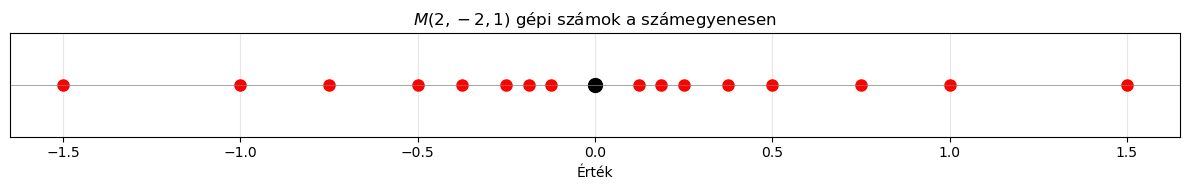

In [10]:
def gepi_szamok(t, k_min, k_max):
    """M(t, k_min, k_max) gépi számhalmaz előállítása."""
    szamok = {0.0}  # a 0 mindig eleme
    # Minden lehetséges mantissza (m1=1 fix, m2..mt szabad)
    for bits in range(2**(t - 1)):  # t-1 szabad bit
        # Mantissza: 0.1m2m3...mt
        m = 0.5  # m1 = 1 -> 2^{-1}
        for i in range(t - 1):
            if bits & (1 << (t - 2 - i)):
                m += 2**(-(i + 2))
        for k in range(k_min, k_max + 1):
            ertek = m * (2**k)
            szamok.add(ertek)
            szamok.add(-ertek)
    return sorted(szamok)

# M(2, -2, 1) - a prezentációban M(3,-1,2) van, ez más
t, k_min, k_max = 2, -2, 1
M = gepi_szamok(t, k_min, k_max)

eps0 = 2**(k_min - 1)
eps1 = 2**(1 - t)
M_inf = (1 - 2**(-t)) * 2**k_max
M_db = 2 * 2**(t-1) * (k_max - k_min + 1) + 1

print(f'M({t}, {k_min}, {k_max}) gépi számhalmaz')
print(f'Elemei: {M}')
print(f'\nε₀ = {eps0} (legkisebb pozitív)')
print(f'ε₁ = {eps1} (gépi epsilon)')
print(f'M∞ = {M_inf} (legnagyobb)')
print(f'|M| = {M_db} (elemek száma)')

# Vizualizáció
plt.figure(figsize=(12, 2))
pozitiv = [x for x in M if x > 0]
negativ = [x for x in M if x < 0]
plt.plot(M, [0]*len(M), 'ro', markersize=8)
plt.plot(0, 0, 'ko', markersize=10)  # 0 kiemelve
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.xlabel('Érték')
plt.title(f'$M({t}, {k_min}, {k_max})$ gépi számok a számegyenesen')
plt.yticks([])
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Valós Python float értékek (double ~ M(52, -1024, 1023))
import sys

info = sys.float_info
print('Python float (IEEE 754 double) jellemzői:')
print(f'  Mantissza jegyek (t):  {info.mant_dig}')
print(f'  Gépi epszilon (ε₁):   {info.epsilon}')
print(f'  Legkisebb norm. (min): {info.min}')
print(f'  Legnagyobb (max):      {info.max}')
print(f'  Max. kitevő (k+):      {info.max_exp}')
print(f'  Min. kitevő (k-):      {info.min_exp}')

Python float (IEEE 754 double) jellemzői:
  Mantissza jegyek (t):  53
  Gépi epszilon (ε₁):   2.220446049250313e-16
  Legkisebb norm. (min): 2.2250738585072014e-308
  Legnagyobb (max):      1.7976931348623157e+308
  Max. kitevő (k+):      1024
  Min. kitevő (k-):      -1021


---
## 5. Input hiba szemléltetése

Az $fl(x)$ input függvény $x$-hez a legközelebbi gépi számot rendeli.

**Tétel:** Ha $\varepsilon_0 \le |x| \le M_\infty$, akkor a relatív hiba:
$$\frac{|x - fl(x)|}{|x|} \le \frac{1}{2} \varepsilon_1 = 2^{-t}.$$

Ellenőrizzük ezt kísérletileg, float32-re ($t = 23$, tehát $\varepsilon_1/2 \approx 5.96 \times 10^{-8}$)!

float32 gépi epszilon (ε₁):   1.192093e-07
Elméleti korlát (ε₁/2):        5.960464e-08
Maximális mért relatív hiba:   5.926674e-08
Korlát teljesül? True


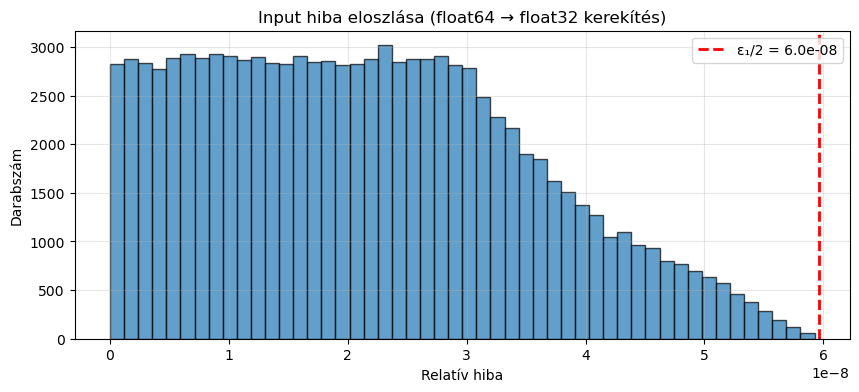

In [12]:
# Véletlenszerű számok float64-ben -> kerekítés float32-re -> relatív hiba
np.random.seed(42)
x_64 = np.random.uniform(-1e10, 1e10, size=100000).astype(np.float64)
x_32 = x_64.astype(np.float32).astype(np.float64)  # float32-re kerekítve, vissza float64-re

# Relatív hiba
rel_hiba = np.abs(x_64 - x_32) / np.abs(x_64)

eps1_float32 = np.finfo(np.float32).eps  # 2^{1-23} = 2^{-22}
korlat = eps1_float32 / 2  # 2^{-23}

print(f'float32 gépi epszilon (ε₁):   {eps1_float32:.6e}')
print(f'Elméleti korlát (ε₁/2):        {korlat:.6e}')
print(f'Maximális mért relatív hiba:   {np.max(rel_hiba):.6e}')
print(f'Korlát teljesül? {np.all(rel_hiba <= korlat + 1e-15)}')

plt.figure(figsize=(10, 4))
plt.hist(rel_hiba, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=korlat, color='red', linestyle='--', linewidth=2, label=f'ε₁/2 = {korlat:.1e}')
plt.xlabel('Relatív hiba')
plt.ylabel('Darabszám')
plt.title('Input hiba eloszlása (float64 → float32 kerekítés)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 6. Hibák terjedése

### Az alapműveletek hibái

| Művelet | Abszolút hibakorlát | Relatív hibakorlát |
|---|---|---|
| $a \pm b$ | $\Delta_{a \pm b} = \Delta_a + \Delta_b$ | $\delta_{a \pm b} = \frac{\|a\| \cdot \delta_a + \|b\| \cdot \delta_b}{\|a \pm b\|}$ |
| $a \cdot b$ | $\Delta_{a \cdot b} = \|b\| \cdot \Delta_a + \|a\| \cdot \Delta_b$ | $\delta_{a \cdot b} = \delta_a + \delta_b$ |
| $a / b$ | $\Delta_{a/b} = \frac{\|b\| \cdot \Delta_a + \|a\| \cdot \Delta_b}{b^2}$ | $\delta_{a/b} = \delta_a + \delta_b$ |

**Veszélyes esetek:**
1. Közeli számok kivonása → relatív hiba felerősödik
2. Kis számmal való osztás → abszolút hiba felerősödik

In [13]:
# Példa: közeli számok kivonása FÜGGETLEN hibákkal
print('=== Katasztrofális kioltás: közeli számok kivonása ===')
print()

# Pontos értékek
A_pontos = 1.000000
B_pontos = 0.999999

# Független mérési hibák: ±1e-6 abszolút hiba mindkét számban
Delta_a = 1.2e-6  # A mérési hibája
Delta_b = -0.8e-6  # B mérési hibája (más irányú!)
A_mert = A_pontos + Delta_a
B_mert = B_pontos + Delta_b

kul_pontos = A_pontos - B_pontos
kul_mert = A_mert - B_mert

print(f'A = {A_pontos}, B = {B_pontos}')
print(f'A - B (pontos)   = {kul_pontos:.10e}')
print(f'A bemeneti abszolút hibája: {Delta_a:.1e}')
print(f'B bemeneti abszolút hibája: {Delta_b:.1e}')
print(f'A bemeneti relatív hibája:  {abs(Delta_a/A_pontos):.4%}')
print()
print(f"A' = {A_mert}, B' = {B_mert}")
print(f"A' - B' (mért)   = {kul_mert:.10e}")
print(f'Az eredmény abszolút hibája: {abs(kul_mert - kul_pontos):.2e}')
print(f'Az eredmény relatív hibája:  {abs(kul_mert - kul_pontos) / abs(kul_pontos):.0%}')
print()
print(f'A bemeneti abszolút hiba ~1e-6, de az eredmény relatív hibája {abs(kul_mert - kul_pontos) / abs(kul_pontos):.0%}!')
print('Ez azért van, mert Δ(a-b) = Δa + Δb, de |a-b| nagyon kicsi.')

=== Katasztrofális kioltás: közeli számok kivonása ===

A = 1.0, B = 0.999999
A - B (pontos)   = 1.0000000000e-06
A bemeneti abszolút hibája: 1.2e-06
B bemeneti abszolút hibája: -8.0e-07
A bemeneti relatív hibája:  0.0001%

A' = 1.0000012, B' = 0.9999982
A' - B' (mért)   = 3.0000000001e-06
Az eredmény abszolút hibája: 2.00e-06
Az eredmény relatív hibája:  200%

A bemeneti abszolút hiba ~1e-6, de az eredmény relatív hibája 200%!
Ez azért van, mert Δ(a-b) = Δa + Δb, de |a-b| nagyon kicsi.


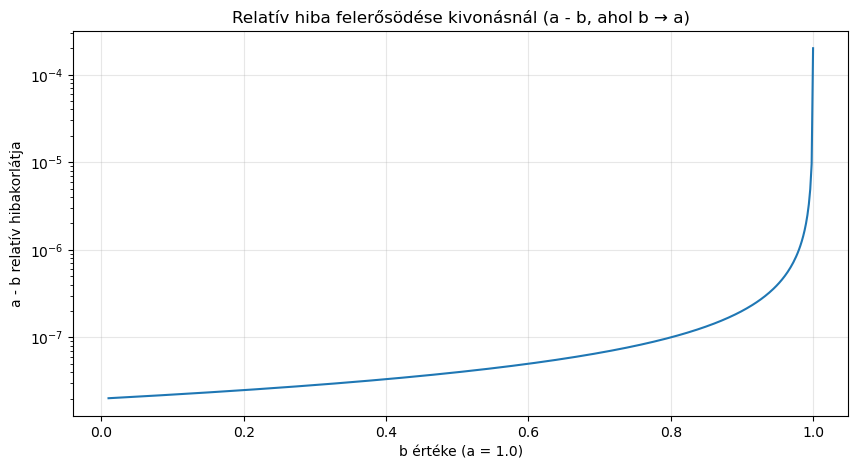

In [14]:
# Szemléltetés: relatív hiba felerősödése a különbség csökkenésével
a = 1.0
b_ertekek = np.linspace(0.01, 0.9999, 500)
delta_a = 1e-8  # a abszolút hibája
delta_b = 1e-8  # b abszolút hibája

# a - b relatív hibájának korlátja
delta_rel_eredmeny = (abs(a) * (delta_a / abs(a)) + np.abs(b_ertekek) * (delta_b / np.abs(b_ertekek))) / np.abs(a - b_ertekek)

plt.figure(figsize=(10, 5))
plt.semilogy(b_ertekek, delta_rel_eredmeny)
plt.xlabel('b értéke (a = 1.0)')
plt.ylabel('a - b relatív hibakorlátja')
plt.title('Relatív hiba felerősödése kivonásnál (a - b, ahol b → a)')
plt.grid(True, alpha=0.3)
plt.show()

### Függvényérték hibája és kondíciószám

Ha $f \in C^1$ és $a$ bemeneti adat hibája $\Delta_a$, akkor:
$$\Delta_{f(a)} \approx |f'(a)| \cdot \Delta_a$$

A függvény $a$-beli **kondíciószáma**:
$$c(f, a) = \frac{|a| \cdot |f'(a)|}{|f(a)|}$$

Ha $c(f, a) \gg 1$, a feladat **rosszul kondicionált** $a$-ban.

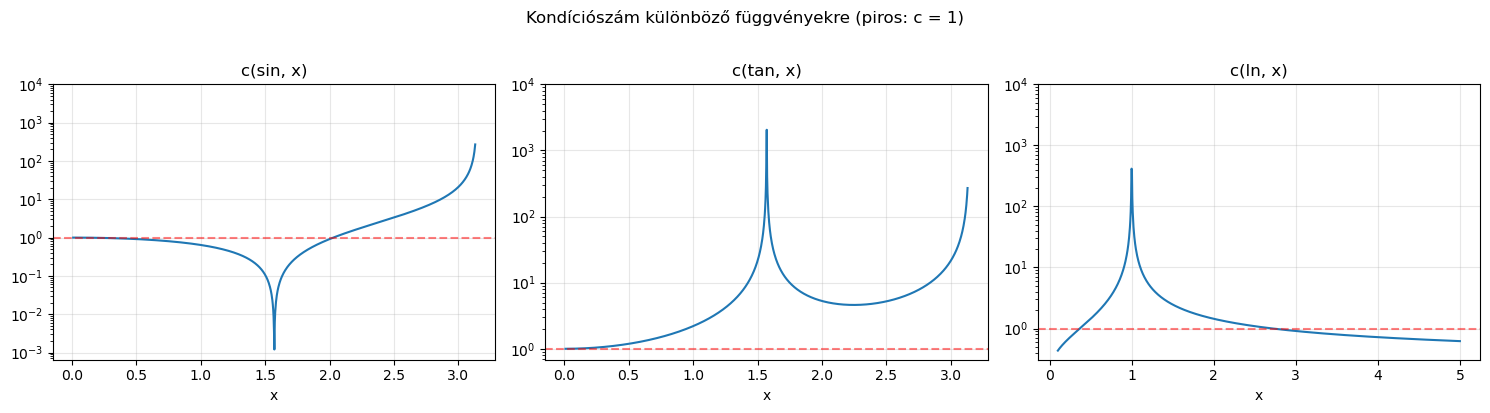

sin(x): rosszul kondicionált x ≈ kπ környékén (sin ≈ 0)
tan(x): rosszul kondicionált x ≈ 0 és x ≈ π/2 környékén
ln(x):  rosszul kondicionált x ≈ 1 környékén (ln(1) = 0)


In [15]:
# Kondíciószám vizsgálata különböző függvényekre

# 1. f(x) = sin(x), f'(x) = cos(x)
# c(sin, a) = |a * cos(a)| / |sin(a)|
x = np.linspace(0.01, 3.13, 1000)
cond_sin = np.abs(x * np.cos(x)) / np.abs(np.sin(x))

# 2. f(x) = tan(x), f'(x) = 1/cos^2(x)
# c(tan, a) = |a / (cos^2(a) * tan(a))| = |a / (sin(a)*cos(a))|
cond_tan = np.abs(x / (np.sin(x) * np.cos(x)))

# 3. f(x) = ln(x), f'(x) = 1/x
# c(ln, a) = |a * (1/a)| / |ln(a)| = 1 / |ln(a)|
x_ln = np.linspace(0.1, 5, 1000)
cond_ln = 1.0 / np.abs(np.log(x_ln))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(x, cond_sin)
axes[0].set_title('c(sin, x)')
axes[0].set_xlabel('x')
axes[0].set_ylim(top=1e4)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=1, color='r', linestyle='--', alpha=0.5)

axes[1].semilogy(x, cond_tan)
axes[1].set_title('c(tan, x)')
axes[1].set_xlabel('x')
axes[1].set_ylim(top=1e4)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=1, color='r', linestyle='--', alpha=0.5)

axes[2].semilogy(x_ln, cond_ln)
axes[2].set_title('c(ln, x)')
axes[2].set_xlabel('x')
axes[2].set_ylim(top=1e4)
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=1, color='r', linestyle='--', alpha=0.5)

plt.suptitle('Kondíciószám különböző függvényekre (piros: c = 1)', y=1.02)
plt.tight_layout()
plt.show()

print('sin(x): rosszul kondicionált x ≈ kπ környékén (sin ≈ 0)')
print('tan(x): rosszul kondicionált x ≈ 0 és x ≈ π/2 környékén')
print('ln(x):  rosszul kondicionált x ≈ 1 környékén (ln(1) = 0)')

In [16]:
# Konkrét példa: ln(x) rosszul kondicionált x = 1 közelében
print('=== ln(x) kondicionáltsága x = 1 közelében ===')
print()

for a in [1.001, 1.0001, 1.00001]:
    c_fa = abs(a * (1/a)) / abs(np.log(a))  # = 1/|ln(a)|
    print(f'a = {a}, ln(a) = {np.log(a):.6e}, c(ln, a) = {c_fa:.1f}')
    print(f'  → Ha a bemeneti relatív hiba 1e-10, az eredmény relatív hibája ≈ {c_fa * 1e-10:.2e}')
    print()

=== ln(x) kondicionáltsága x = 1 közelében ===

a = 1.001, ln(a) = 9.995003e-04, c(ln, a) = 1000.5
  → Ha a bemeneti relatív hiba 1e-10, az eredmény relatív hibája ≈ 1.00e-07

a = 1.0001, ln(a) = 9.999500e-05, c(ln, a) = 10000.5
  → Ha a bemeneti relatív hiba 1e-10, az eredmény relatív hibája ≈ 1.00e-06

a = 1.00001, ln(a) = 9.999950e-06, c(ln, a) = 100000.5
  → Ha a bemeneti relatív hiba 1e-10, az eredmény relatív hibája ≈ 1.00e-05

